# Feature Engineering for Healthcare Risk Analysis

This notebook focuses on creating analytical features that may help better understand patient complexity, healthcare utilization, and hospital readmission risk.

Feature engineering transforms raw healthcare variables into more meaningful indicators that can support advanced analytics and predictive modeling.

In [2]:
%pip install seaborn

## Importing Libraries and Dataset

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Healthcare Utilization Score

This feature combines outpatient, emergency, and inpatient visits into a single utilization metric representing overall healthcare service usage.

In [4]:
df = pd.read_csv(
    "/drive/hospital-readmission-project/data/cleaned_hospital_data.csv"
)

In [5]:
df["utilization_score"] = (
    df["number_outpatient"] +
    df["number_emergency"] +
    df["number_inpatient"]
)

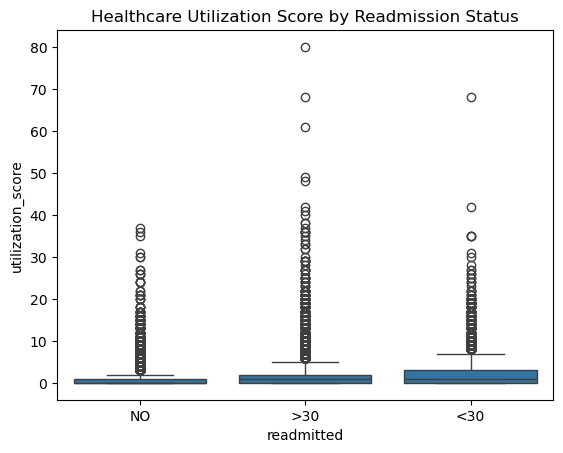

In [6]:
sns.boxplot(
    data=df,
    x="readmitted",
    y="utilization_score"
)
plt.title("Healthcare Utilization Score by Readmission Status")
plt.show()

### Insight

Patients with higher healthcare utilization scores appear more likely to experience hospital readmission, potentially reflecting chronic conditions or increased clinical complexity.

## Medication Complexity Feature

This feature combines medication count and diagnosis volume to estimate patient treatment complexity.

In [7]:
df["medication_complexity"] = (
    df["num_medications"] *
    df["number_diagnoses"]
)

In [8]:
df["medication_complexity"].describe()

count    101766.000000
mean        123.033813
std          75.400474
min           1.000000
25%          70.000000
50%         108.000000
75%         162.000000
max        1040.000000
Name: medication_complexity, dtype: float64

### Insight

Higher medication complexity may indicate patients managing multiple chronic conditions and more intensive treatment plans.

In [9]:
# Composite healthcare risk score
df["risk_score"] = (
    df["time_in_hospital"] +
    df["num_medications"] +
    df["number_diagnoses"] +
    df["utilization_score"]
)

In [10]:
df["risk_category"] = pd.qcut(
    df["risk_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

## Composite Patient Risk Score

A custom risk score was developed by combining hospitalization duration, medication burden, diagnosis count, and healthcare utilization patterns.

The objective is to create a simplified indicator of overall patient complexity and potential readmission risk.

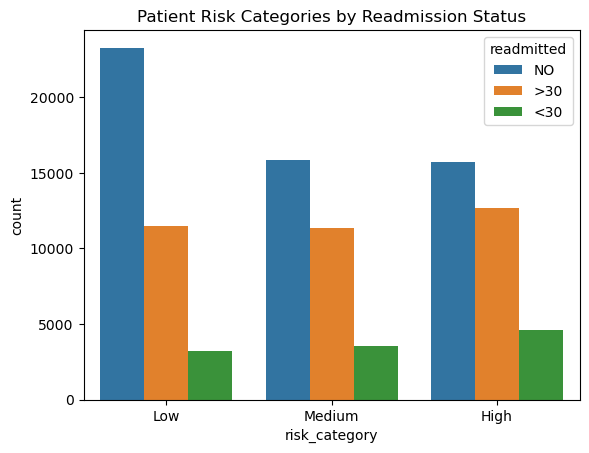

In [11]:
sns.countplot(
    data=df,
    x="risk_category",
    hue="readmitted"
)
plt.title("Patient Risk Categories by Readmission Status")
plt.show()

### Insight

Patients classified within the high-risk category appear to demonstrate increased readmission frequency compared to lower-risk groups.

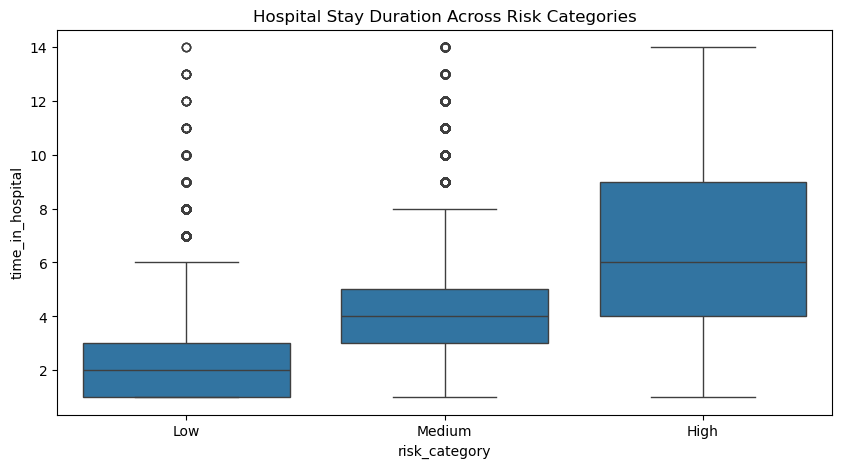

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="risk_category",
    y="time_in_hospital"
)

plt.title("Hospital Stay Duration Across Risk Categories")

plt.show()

### Insight

Higher risk categories are associated with longer hospital stays, supporting the effectiveness of the engineered risk scoring approach.

In [13]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,utilization_score,medication_complexity,risk_score,risk_category
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,...,No,No,No,No,No,NO,0,1,3,Low
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,No,No,Ch,Yes,>30,0,162,30,Medium
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,Yes,NO,3,78,24,Low
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,No,No,Ch,Yes,NO,0,112,25,Medium
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,No,No,Ch,Yes,NO,0,40,14,Low


# Feature Engineering Conclusion

Feature engineering enabled the transformation of raw clinical and operational variables into more meaningful healthcare indicators.

The engineered features developed in this notebook may support future predictive modeling workflows related to hospital readmission risk, patient complexity, and healthcare utilization analysis.

In [14]:
df.to_csv(
    "/drive/hospital-readmission-project/data/featured_hospital_data.csv",
    index=False
)

In [15]:
import os

os.listdir("/drive/hospital-readmission-project/data")

['cleaned_hospital_data.csv',
 'diabetic_data.csv',
 'featured_hospital_data.csv']